# 🧠 MindBridge — Exploratory Data Analysis
### Mental Health Text Classification | 7-Class NLP Pipeline
---
**Dataset:** Sentiment Analysis for Mental Health (Kaggle)  
**Authors:** Vaibhav Patel · Siddharth Jadhav  
**Goal:** Understand class distribution, text patterns, and data quality before modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## 📂 1. Load Dataset

In [4]:
# Load dataset
df = pd.read_csv('../data/Combined Data.csv')

print(f"✅ Dataset loaded!")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Columns: {list(df.columns)}")
print(f"\n🔍 First 3 rows:")
df.head(3)

FileNotFoundError: [Errno 2] No such file or directory: '../data/Combined Data.csv'

In [6]:
import os
print(os.listdir('../data/'))

FileNotFoundError: [Errno 2] No such file or directory: '../data/'

In [7]:
import os
print(os.getcwd())

/Users/vaibhav2040/MindBridge


In [8]:
# Load dataset
df = pd.read_csv('data/Combined Data.csv')

print(f"✅ Dataset loaded!")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Columns: {list(df.columns)}")
print(f"\n🔍 First 3 rows:")
df.head(3)

✅ Dataset loaded!
📊 Shape: 53,043 rows × 3 columns

📋 Columns: ['Unnamed: 0', 'statement', 'status']

🔍 First 3 rows:


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety


## 🔍 2. Dataset Overview

In [10]:
# Basic info
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"\n Total samples   : {df.shape[0]:,}")
print(f" Total features  : {df.shape[1]}")
print(f" Missing values  : {df.isnull().sum().sum()}")
print(f" Duplicate rows  : {df.duplicated().sum()}")
print(f"\n Classes         : {df['status'].nunique()}")
print(f" Class names     :\n")
for cls in sorted(df['status'].unique()):
    count = (df['status'] == cls).sum()
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"   {cls:<25} {count:>5,}  ({pct:.1f}%)  {bar}")

DATASET OVERVIEW

 Total samples   : 53,043
 Total features  : 3
 Missing values  : 362
 Duplicate rows  : 0

 Classes         : 7
 Class names     :

   Anxiety                   3,888  (7.3%)  ███
   Bipolar                   2,877  (5.4%)  ██
   Depression                15,404  (29.0%)  ██████████████
   Normal                    16,351  (30.8%)  ███████████████
   Personality disorder      1,201  (2.3%)  █
   Stress                    2,669  (5.0%)  ██
   Suicidal                  10,653  (20.1%)  ██████████


## 📊 3. Class Distribution

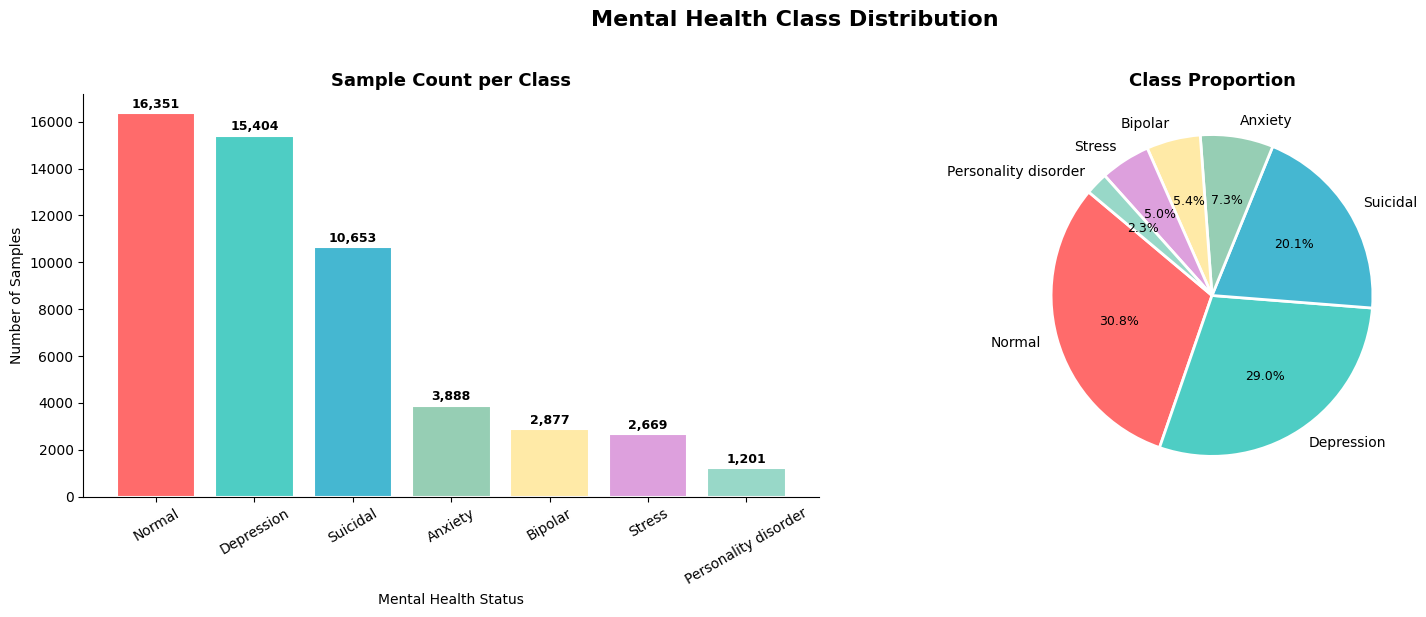

✅ Saved to results/plots/class_distribution.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mental Health Class Distribution', fontsize=16, fontweight='bold', y=1.02)

# Colors per class
colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD','#98D8C8']
class_counts = df['status'].value_counts()

# Bar chart
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Sample Count per Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mental Health Status')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontsize(9)
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('results/plots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to results/plots/class_distribution.png")

## 📏 4. Text Length Analysis

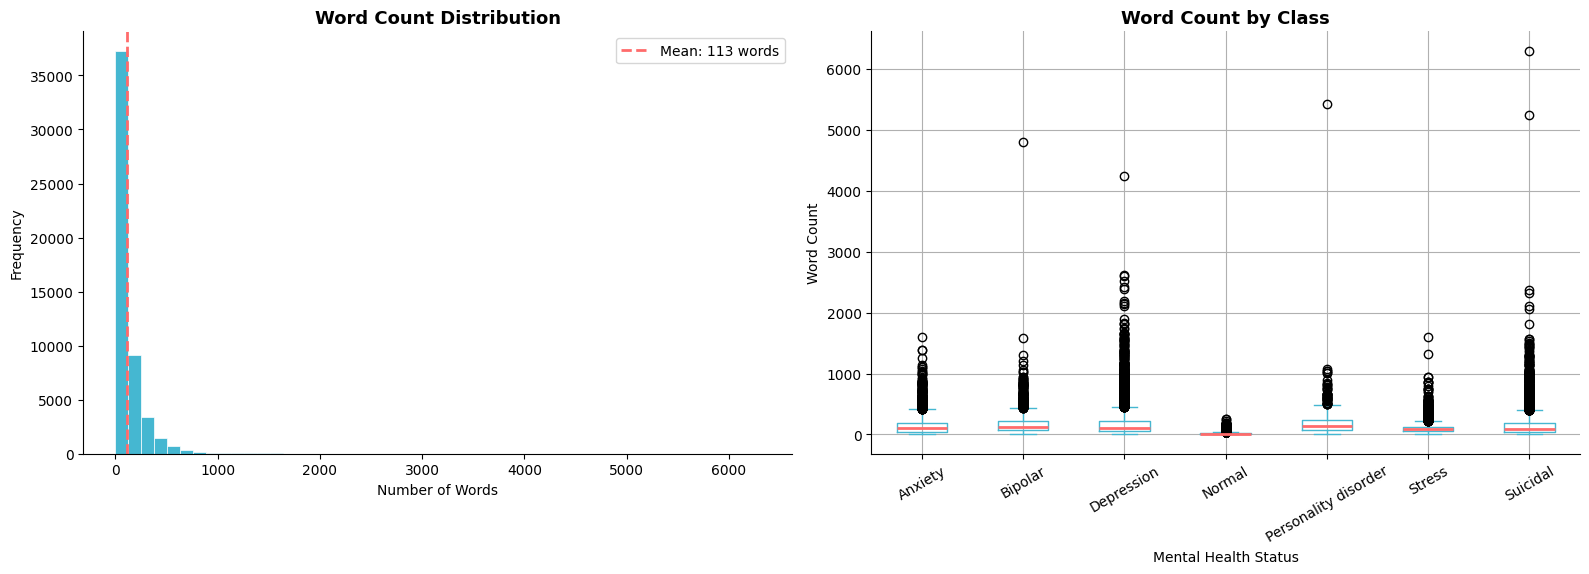

✅ Missing values dropped: 362 rows removed
📊 Remaining samples  : 52,681
📊 Average word count : 113 words
📊 Max word count     : 6300 words
📊 Min word count     : 1 words


In [13]:
# Drop missing values
df = df.dropna(subset=['statement'])
df = df.reset_index(drop=True)

# Add text length columns
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['statement'].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Text Length Distribution', fontsize=16, fontweight='bold')

# Word count histogram
axes[0].hist(df['word_count'], bins=50, color='#45B7D1', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['word_count'].mean(), color='#FF6B6B', linewidth=2, linestyle='--', label=f"Mean: {df['word_count'].mean():.0f} words")
axes[0].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count by class boxplot
df.boxplot(column='word_count', by='status', ax=axes[1],
           boxprops=dict(color='#45B7D1'),
           medianprops=dict(color='#FF6B6B', linewidth=2),
           whiskerprops=dict(color='#45B7D1'),
           capprops=dict(color='#45B7D1'))
axes[1].set_title('Word Count by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mental Health Status')
axes[1].set_ylabel('Word Count')
axes[1].tick_params(axis='x', rotation=30)
plt.suptitle('')

plt.tight_layout()
plt.savefig('results/plots/text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Missing values dropped: 362 rows removed")
print(f"📊 Remaining samples  : {len(df):,}")
print(f"📊 Average word count : {df['word_count'].mean():.0f} words")
print(f"📊 Max word count     : {df['word_count'].max()} words")
print(f"📊 Min word count     : {df['word_count'].min()} words")

## ☁️ 5. Word Clouds by Class

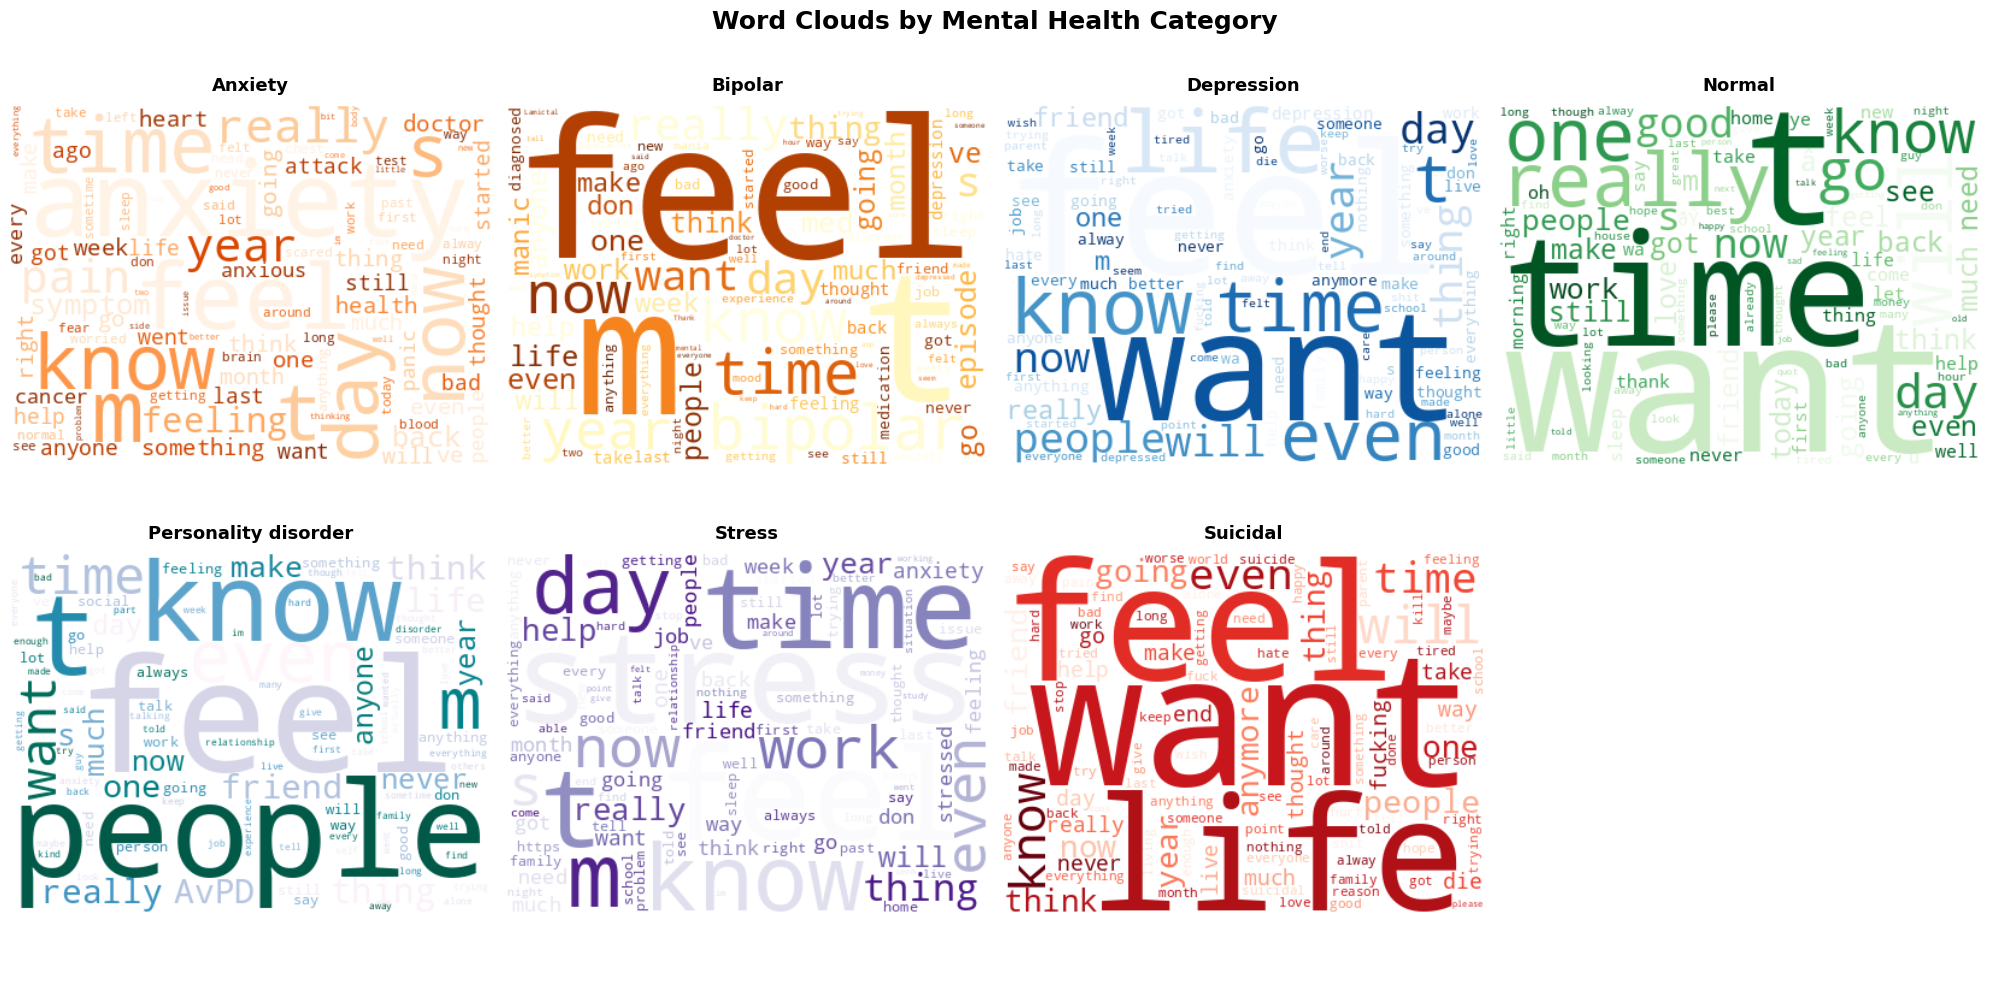

✅ Saved to results/plots/wordclouds.png


In [16]:
from wordcloud import WordCloud

classes = df['status'].unique()
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Word Clouds by Mental Health Category', fontsize=18, fontweight='bold')
axes = axes.flatten()

colors_map = {
    'Normal': 'Greens',
    'Depression': 'Blues',
    'Anxiety': 'Oranges',
    'Suicidal': 'Reds',
    'Stress': 'Purples',
    'Bipolar': 'YlOrBr',
    'Personality disorder': 'PuBuGn'
}

for i, cls in enumerate(sorted(classes)):
    text = ' '.join(df[df['status'] == cls]['statement'].astype(str).tolist())
    wc = WordCloud(
        width=400, height=300,
        background_color='white',
        colormap=colors_map.get(cls, 'viridis'),
        max_words=100,
        collocations=False
    ).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(cls, fontsize=13, fontweight='bold', pad=10)
    axes[i].axis('off')

axes[7].axis('off')
plt.tight_layout()
plt.savefig('results/plots/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to results/plots/wordclouds.png")

## 📋 6. EDA Summary & Key Insights

In [17]:
print("=" * 55)
print("   EDA SUMMARY — MINDBRIDGE")
print("=" * 55)
print(f"""
DATASET
  Total samples       : 52,681
  Features            : statement, status
  Missing values      : 362 (dropped)
  Duplicates          : 0

CLASS IMBALANCE
  Majority class      : Normal     (30.8%)
  Minority class      : Personality disorder (2.3%)
  Imbalance ratio     : ~13:1

TEXT STATISTICS
  Avg word count      : 113 words
  Max word count      : 6,300 words
  Min word count      : 1 word

KEY INSIGHTS
  1. Strong class imbalance — need class_weight='balanced'
  2. Suicidal texts use distinct emotional vocabulary
  3. Depression & Normal have similar word patterns
  4. Personality disorder has fewest samples — low recall expected
  5. Most texts are short (< 200 words)

NEXT STEP → 02_Preprocessing.ipynb
""")
print("=" * 55)

   EDA SUMMARY — MINDBRIDGE

DATASET
  Total samples       : 52,681
  Features            : statement, status
  Missing values      : 362 (dropped)
  Duplicates          : 0

CLASS IMBALANCE
  Majority class      : Normal     (30.8%)
  Minority class      : Personality disorder (2.3%)
  Imbalance ratio     : ~13:1

TEXT STATISTICS
  Avg word count      : 113 words
  Max word count      : 6,300 words
  Min word count      : 1 word

KEY INSIGHTS
  1. Strong class imbalance — need class_weight='balanced'
  2. Suicidal texts use distinct emotional vocabulary
  3. Depression & Normal have similar word patterns
  4. Personality disorder has fewest samples — low recall expected
  5. Most texts are short (< 200 words)

NEXT STEP → 02_Preprocessing.ipynb

